In [ ]:
# Load single-qubit data saved by the two-qubit calculation and print qubit-frequency detuning
import sys
from pathlib import Path
import numpy as np

# ../ham_data.py contains load_1q_data_for_2q
sys.path.insert(0, str(Path('..').resolve()))
import ham_data as hd

# Folder containing two_qubit_data.npz; change this path if you want another dataset.
folder_load = Path('../data/Two_qubit_data_Sorted_Untruc')

# load_1q_data_for_2q returns eigenvalues scaled by 2π, i.e. angular frequencies
# relative transition frequencies in GHz are therefore omega / (2π).
eval0, eval1, n_theta0, n_theta1 = hd.load_1q_data_for_2q(folder_load)

# Zero-pi logical qubit transition is |0> -> |2> in this project.
logical_ground = 0
logical_excited = 2

omega_q0 = eval0[logical_excited] - eval0[logical_ground]
omega_q1 = eval1[logical_excited] - eval1[logical_ground]
delta_omega = omega_q0 - omega_q1

freq_q0_ghz = omega_q0 / (2 * np.pi)
freq_q1_ghz = omega_q1 / (2 * np.pi)
detuning_ghz = delta_omega / (2 * np.pi)

print(f"Loaded 1Q data from: {folder_load}")
print(f"Zero-pi qubit 0 frequency |{logical_ground}>→|{logical_excited}>: {freq_q0_ghz:.9f} GHz")
print(f"Zero-pi qubit 1 frequency |{logical_ground}>→|{logical_excited}>: {freq_q1_ghz:.9f} GHz")
print(f"Detuning q0 - q1: {detuning_ghz:.9f} GHz ({detuning_ghz * 1e3:.6f} MHz)")
print(f"Angular detuning q0 - q1: {delta_omega:.9f} rad/ns")


Loaded 1Q data from: ../data/Two_qubit_data_Sorted_Untruc
Zero-pi qubit 0 frequency |0>→|2>: 3.443399830 GHz
Zero-pi qubit 1 frequency |0>→|2>: 3.409953268 GHz
Detuning q0 - q1: 0.033446562 GHz (33.446562 MHz)
Angular detuning q0 - q1: 0.210150945 rad/ns


99.9% coherent fidelity check
threshold log10(1-F) = -3.0
optimal detune = 0.013127000 GHz
frequency window = 0.012627000 to 0.013627000 GHz
frequency-window sampled points = 15
minimum F in frequency window = 0.99904341
maximum log10(1-F) in frequency window = -3.01927379
frequency window passes F >= 99.9%: True

optimal amp = 0.007880000
2% amp window = 0.007722400 to 0.008037600
amp-window sampled points = 5
minimum F in amp window = 0.99909232
maximum log10(1-F) in amp window = -3.04206945
drive-amplitude window passes F >= 99.9%: True


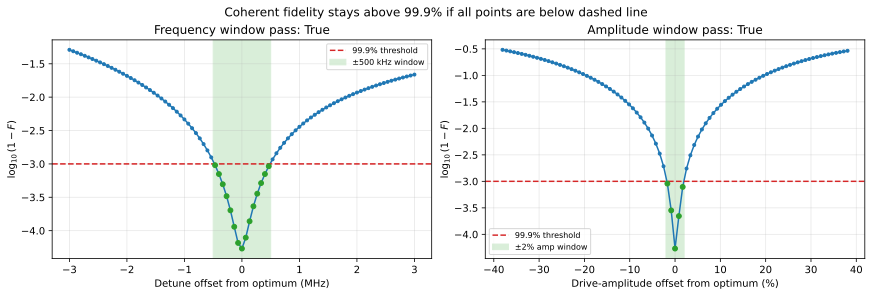

In [3]:
# Check whether coherent fidelity stays above 99.9% in target windows
# Criterion: F >= 0.999  <=>  1-F <= 1e-3  <=>  log10(1-F) <= -3
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

log_path = Path("data/sensitivity/sensitivity_truc30tg182_dim91.txt")
text = log_path.read_text()


def read_np_array(name, text=text):
    pattern = rf"{re.escape(name)}\s*=\s*np\.array\(\s*(\[.*?\])\s*\)"
    match = re.search(pattern, text, flags=re.S)
    if match is None:
        raise KeyError(f"Could not find {name} in {log_path}")
    return np.array(eval(match.group(1).replace(",\n", ",")), dtype=float)

amp = read_np_array("amp_sweep_col1")
detune_ghz = read_np_array("detune_sweep_col2_GHz")
amp_log_errors = read_np_array("amp_log_errors")
detune_log_errors = read_np_array("detune_log_errors")

threshold_log_error = np.log10(1 - 0.999)  # -3

# Use the best sampled point as the optimum for each 1D scan.
opt_amp_idx = int(np.argmin(amp_log_errors))
opt_detune_idx = int(np.argmin(detune_log_errors))
opt_amp = amp[opt_amp_idx]
opt_detune_ghz = detune_ghz[opt_detune_idx]

# Requested windows.
# Interpretation used here: "frequency window of about 500 kHz" = ±500 kHz around optimum.
# If you mean total width 500 kHz instead, change freq_half_width_mhz to 0.25.
freq_half_width_mhz = 0.5
freq_half_width_ghz = freq_half_width_mhz * 1e-3
amp_half_width = 0.02 * opt_amp

freq_mask = np.abs(detune_ghz - opt_detune_ghz) <= freq_half_width_ghz + 1e-15
amp_mask = np.abs(amp - opt_amp) <= amp_half_width + 1e-15

freq_pass = bool(np.all(detune_log_errors[freq_mask] <= threshold_log_error))
amp_pass = bool(np.all(amp_log_errors[amp_mask] <= threshold_log_error))

# Convert to fidelity for easier reporting.
detune_fidelity = 1 - 10**detune_log_errors
amp_fidelity = 1 - 10**amp_log_errors

print("99.9% coherent fidelity check")
print("=" * 60)
print(f"threshold log10(1-F) = {threshold_log_error:.1f}")
print(f"optimal detune = {opt_detune_ghz:.9f} GHz")
print(f"frequency window = {opt_detune_ghz - freq_half_width_ghz:.9f} to {opt_detune_ghz + freq_half_width_ghz:.9f} GHz")
print(f"frequency-window sampled points = {freq_mask.sum()}")
print(f"minimum F in frequency window = {detune_fidelity[freq_mask].min():.8f}")
print(f"maximum log10(1-F) in frequency window = {detune_log_errors[freq_mask].max():.8f}")
print(f"frequency window passes F >= 99.9%: {freq_pass}")
print()
print(f"optimal amp = {opt_amp:.9f}")
print(f"2% amp window = {opt_amp - amp_half_width:.9f} to {opt_amp + amp_half_width:.9f}")
print(f"amp-window sampled points = {amp_mask.sum()}")
print(f"minimum F in amp window = {amp_fidelity[amp_mask].min():.8f}")
print(f"maximum log10(1-F) in amp window = {amp_log_errors[amp_mask].max():.8f}")
print(f"drive-amplitude window passes F >= 99.9%: {amp_pass}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Frequency/detune plot: x-axis shown as offset from optimum in MHz.
detune_offset_mhz = (detune_ghz - opt_detune_ghz) * 1e3
ax[0].plot(detune_offset_mhz, detune_log_errors, marker="o", ms=3)
ax[0].axhline(threshold_log_error, color="C3", ls="--", label="99.9% threshold")
ax[0].axvspan(-freq_half_width_mhz, freq_half_width_mhz, color="C2", alpha=0.18, label="±500 kHz window")
ax[0].scatter(detune_offset_mhz[freq_mask], detune_log_errors[freq_mask], color="C2", zorder=3, s=24)
ax[0].set_xlabel("Detune offset from optimum (MHz)")
ax[0].set_ylabel(r"$\log_{10}(1-F)$")
ax[0].set_title(f"Frequency window pass: {freq_pass}")
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8)

# Drive-amplitude plot: x-axis shown as percent offset from optimum.
amp_offset_percent = (amp / opt_amp - 1) * 100
ax[1].plot(amp_offset_percent, amp_log_errors, marker="o", ms=3)
ax[1].axhline(threshold_log_error, color="C3", ls="--", label="99.9% threshold")
ax[1].axvspan(-2, 2, color="C2", alpha=0.18, label="±2% amp window")
ax[1].scatter(amp_offset_percent[amp_mask], amp_log_errors[amp_mask], color="C2", zorder=3, s=24)
ax[1].set_xlabel("Drive-amplitude offset from optimum (%)")
ax[1].set_ylabel(r"$\log_{10}(1-F)$")
ax[1].set_title(f"Amplitude window pass: {amp_pass}")
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)

fig.suptitle("Coherent fidelity stays above 99.9% if all points are below dashed line")
plt.show()


# Fig

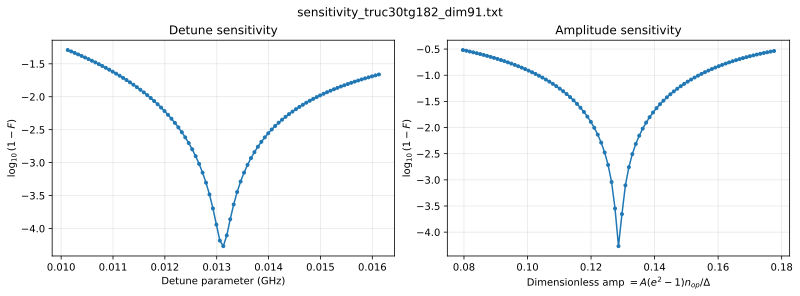

Loaded 91 amplitude points and 91 detune points
detune/(2π) = 33.45 MHz, nop = 0.537
dimensionless amp range: 0.0796627 to 0.177609


In [ ]:
# Plot sensitivity data from text log
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

log_path = Path("data/sensitivity/sensitivity_truc30tg182_dim91.txt")
text = log_path.read_text()


def read_np_array(name, text=text):
    """Read arrays printed as: name = np.array([...]) from the log file."""
    pattern = rf"{re.escape(name)}\s*=\s*np\.array\(\s*(\[.*?\])\s*\)"
    match = re.search(pattern, text, flags=re.S)
    if match is None:
        raise KeyError(f"Could not find {name} in {log_path}")
    array_text = match.group(1).replace(",\n", ",")
    return np.array(eval(array_text), dtype=float)

amp = read_np_array("amp_sweep_col1")
detune_ghz = read_np_array("detune_sweep_col2_GHz")
amp_log_errors = read_np_array("amp_log_errors")
detune_log_errors = read_np_array("detune_log_errors")

# User-specified conversion:
# dimensionless_amp = amp * (e**2 - 1) * nop / detune,
# with nop=0.537 and detune/(2*pi)=33.45 MHz.
nop = 0.537
detune_over_2pi_mhz = 33.45
detune_ang_ghz = 2 * np.pi * detune_over_2pi_mhz * 1e-3  # angular detune in GHz
amp_dimensionless = amp * (np.e**2 - 1) * nop / detune_ang_ghz

fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax[0].plot(detune_ghz, detune_log_errors, marker="o", ms=3)
ax[0].set_xlabel("Detune parameter (GHz)")
ax[0].set_ylabel(r"$\log_{10}(1-F)$")
ax[0].set_title("Detune sensitivity")
ax[0].grid(True, alpha=0.3)

ax[1].plot(amp_dimensionless, amp_log_errors, marker="o", ms=3)
ax[1].set_xlabel(r"Dimensionless amp $= A(e^2-1)n_{op}/\Delta$")
ax[1].set_ylabel(r"$\log_{10}(1-F)$")
ax[1].set_title("Amplitude sensitivity")
ax[1].grid(True, alpha=0.3)

fig.suptitle(log_path.name)
plt.show()

print(f"Loaded {len(amp)} amplitude points and {len(detune_ghz)} detune points")
print(f"detune/(2π) = {detune_over_2pi_mhz} MHz, nop = {nop}")
print(f"dimensionless amp range: {amp_dimensionless.min():.6g} to {amp_dimensionless.max():.6g}")


 /tmp/ipykernel_2093618/2844615196.py: 33UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
 /tmp/ipykernel_2093618/2844615196.py: 41

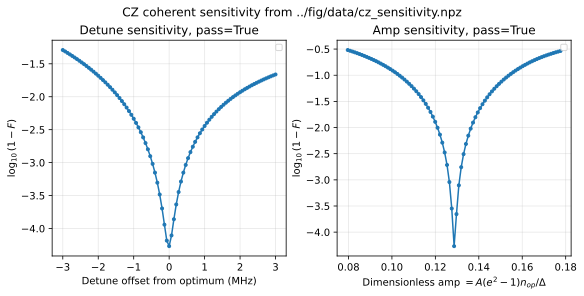

In [8]:
# Import CZ sensitivity data from NPZ and plot
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

npz_path = Path("../figure/data/cz_sensitivity.npz")
data = np.load(npz_path)

amp = data["amp"]
amp_dimensionless = data["amp_dimensionless"]
amp_log_errors = data["amp_log_errors"]
detune_ghz = data["detune_ghz"]
detune_mhz = data["detune_mhz"]
detune_log_errors = data["detune_log_errors"]

threshold_log_error = float(data["threshold_log_error"])
opt_amp = float(data["opt_amp"])
opt_detune_ghz = float(data["opt_detune_ghz"])
freq_half_width_mhz = float(data["freq_half_width_mhz"])
amp_percent_half_width = float(data["amp_percent_half_width"])
freq_mask = data["freq_mask"].astype(bool)
amp_mask = data["amp_mask"].astype(bool)

fig, ax = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

# Detune plot: log error vs detune offset in MHz.
detune_offset_mhz = (detune_ghz - opt_detune_ghz) * 1e3
ax[0].plot(detune_offset_mhz, detune_log_errors, marker="o", ms=3)
ax[0].set_xlabel("Detune offset from optimum (MHz)")
ax[0].set_ylabel(r"$\log_{10}(1-F)$")
ax[0].set_title(f"Detune sensitivity, pass={freq_pass}")
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8)

# Amplitude plot: log error vs dimensionless amplitude.
ax[1].plot(amp_dimensionless, amp_log_errors, marker="o", ms=3)
ax[1].set_xlabel(r"Dimensionless amp $= A(e^2-1)n_{op}/\Delta$")
ax[1].set_ylabel(r"$\log_{10}(1-F)$")
ax[1].set_title(f"Amp sensitivity, pass={amp_pass}")
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)

fig.suptitle("CZ coherent sensitivity from ../fig/data/cz_sensitivity.npz")
plt.show()